# fable: a 16-component spinor field as dark matter and dark energy

This notebook integrates **Model B**: the real 16-component spinor field `fable`, homogeneous on
the observed sheet, in the standard 4-dimensional reference model, where its scalar bilinear
`s = Ψᵀ σ16 Ψ` dilutes exactly as `s ∝ a^{−3}` and its equation of state is the algebraic
function `w = s V′(s)/V(s) − 1` of the self-interaction potential `V(s)`.  Six potentials are
run with the Rust solver `fable_cosmo` (pure-Rust SUNDIALS 7.8.0 CVODE): the author's mass term
(dust, exactly), a mass term plus a bare cosmological constant, power laws, and three potentials
whose slope changes sign, which take `w` across the phantom divide without any wrong-sign
kinetic term.  For each run: `w(a)`, the crossing of `w = −1` compared with its analytic
location, the CPL fit over the supernova range, the Caldwell–Linder class, a scipy DOP853
cross-check, and for the reference case the three-integrator comparison against Mathematica.
The last section answers, from the numbers, which potential gives a genuine phantom phase in
the past with `w(1) ≈ −0.86`, and what its fitted `(w0, wa)` are.

## 1. How to open a notebook like this one, from a terminal

**What you need.** A Rust toolchain (`cargo`, from https://rustup.rs), Python 3 (3.10 or newer),
`git`, and an internet connection for the one-time setup, which makes a sparse clone of the
platform rustSolveIt engine (the vendored pure-Rust SUNDIALS 7.8.0 that the solver is built on:
`rustSolveIt_Win11_SUNDIALS_7_8_0` on Windows 11, `rustSolveIt_macos-silicon_SUNDIALS_7_8_0` on
Apple-silicon macOS, `rustSolveIt_linux_SUNDIALS_7_8_0` on Linux).  Nothing else is downloaded.

**The three commands.**  From the directory that contains `fable-cosmology/`:

1. Run the setup once.  It creates the virtual environment `.venv`, installs numpy, scipy,
   matplotlib and jupyter into it, clones the engine sparsely into `rust/vendor/rustSolveIt`,
   builds the solver with `cargo build --release` and smoke-tests it:

       bash fable-cosmology/setup.sh
       powershell -ExecutionPolicy Bypass -File fable-cosmology\setup.ps1      (Windows PowerShell)

2. Change into the project:

       cd fable-cosmology

3. Start JupyterLab on the notebooks folder:

       .venv/bin/jupyter lab notebooks/
       .venv\Scripts\jupyter.exe lab notebooks\        (Windows)

A browser tab opens.  Click this notebook in the file list on the left.  When Jupyter asks for a
kernel, pick **`Python 3 (ipykernel)`** -- it is the kernel of the `.venv` you just made, so
numpy, scipy and matplotlib are all there.  Run a cell with **`Shift+Enter`**: the cursor moves
to the next cell, and the outputs (text, tables, figures) appear under the cell.  Run the cells
in order from the top; `Run > Run All Cells` does that in one go.  Every cell finishes in well
under a minute on a laptop.

If a cell says the solver binary is missing, the setup was not run (or not finished): run step 1
again and watch for its last line, `== setup complete`.  To rebuild the solver alone, run
`cargo build --release` inside `rust/fable_cosmo`.

## 2. The words used in this notebook

- **field** -- a quantity defined at every point of space-time.  `fableScalar` is one real number
  per point (a scalar field, written phi); `fable` is sixteen real numbers per point that rotate
  into each other under the symmetry group Spin(4,4) of the 8-dimensional pre-universe (a real
  16-component spinor field, written Psi).
- **Lagrangian** -- the function L of a field and its derivatives whose integral (the action) is
  stationary on the physical solutions.  The field equations follow from it by the
  Euler-Lagrange rule.  In curved space-time L carries the volume factor Sqrt[det g].
- **energy-momentum tensor** T_{mu nu} -- the response of the action to a change of the metric;
  its components measured by an observer are the energy density and the pressures.
- **energy density rho** -- energy per unit volume seen by the observer moving along the time
  coordinate (here rho = T_{44}, the time being x4 on the pre-universe and t in the reference
  models).
- **pressure P** -- the spatial diagonal components of T (P_i = T^i_i, i = 1, 2, 3); the fields
  are homogeneous, so P_1 = P_2 = P_3 = P.
- **equation of state w = P / rho** -- the single number that fixes how the energy density of a
  component dilutes as the universe expands: rho is proportional to a^{-3(1+w)}.
- **scale factor a** -- the size of the observed 3-space relative to today (a = 1 today).
- **redshift z = 1/a - 1** -- what an astronomer measures; z = 0 today, z = 1 when a = 1/2.
- **N = ln a** -- the number of e-folds of expansion; the independent variable of the solver.
  N = -7 is a = 9.1e-4 (z = 1096, just after radiation-matter equality, which with the
  parameters used here is at a_eq = Omega_r0/Omega_m0 = 2.8e-4), N = 0 is today.
- **Hubble rate H = (da/dt)/a** -- the expansion rate; in this notebook it is measured in units
  of its value today, so H(a = 1) = 1.
- **Omega_i** -- the fraction of the critical density 3 H^2 carried by component i (matter m,
  radiation r, or the field).  Today Omega_m = 0.3, Omega_r = 8.4e-5 and the field carries the
  rest, 0.699916.
- **CPL (w0, wa)** -- the Chevallier-Polarski-Linder straight line w(a) = w0 + wa (1 - a): w0 is
  w today, w0 + wa is the value the line extrapolates to at a = 0.  The Supernovae *Unite*
  fits are (w0, wa) = (-0.861, -0.60) and, forcing a constant w, w = -0.764.
- **thawing / freezing** -- a field whose w rises with time (dw/dN > 0) is *thawing* (it starts
  frozen at w = -1 and wakes up); one whose w falls towards -1 is *freezing*.  We read the
  class off the sign of dw/dN over the fit range, not off the potential's name.
- **phantom** -- w < -1.  A canonical scalar field cannot get there (its rho + P = 2 KE >= 0);
  crossing w = -1 is called crossing the phantom divide.
- **dust** -- pressureless matter, w = 0, rho proportional to a^{-3}: what cold dark matter is.
- **cosmological constant** -- a constant energy density, w = -1 exactly.
- **kination** -- a scalar field whose energy is all kinetic: w = +1, rho proportional to a^{-6}.
- **SUNDIALS / CVODE / BDF / Adams** -- SUNDIALS is the Lawrence Livermore suite of solvers for
  differential equations; CVODE is its solver for first-order systems y' = f(x, y); BDF (backward
  differentiation formulas, implicit, for stiff systems) and Adams (explicit-predictor
  multistep, for smooth non-stiff oscillations) are its two families of methods.  The solver
  here uses the pure-Rust port of SUNDIALS 7.8.0 of the rustSolveIt repositories.
- **tolerance** -- CVODE keeps the local error of every step below rtol * |y| + atol; the runs
  use rtol = 1e-10, atol = 1e-12.  The cross-checks re-integrate with scipy at rtol = 1e-11.

## 3. The field, its Lagrangian and its energy-momentum tensor

**On the 8-dimensional pre-universe (what Part VI of the Mathematica notebook proves).**  The
setting is the 4+4 pre-universe with coordinates `X = {x0, …, x7}`, flat metric
`eta = diag(+,+,+,+,−,−,−,−)`, the canonical frame `e = diag(Tan[6Hx0], q, q, q, 1, p, p, p)`
(`q = e^{−a4[Hx4]}/Sin[6Hx0]^{1/6}`, `p = e^{+a4[Hx4]}/Sin[6Hx0]^{1/6}`), `Sqrt[det g] = Sec[6Hx0]`,
observer time `t ≡ x4`, observed 3-space `(x1, x2, x3)`; `a4` is never given a value.

`fable ≡ Ψ(x)` is a real 16-component spinor on the 8-manifold, transforming under `Spin(4,4)`
exactly as the model's `Ψ16` of Section 11 of the Mathematica notebook, with its Dirac matrices
`T16[a]`, the symmetric spinor metric `σ16` (`σ16 . T16[a]` antisymmetric), curved Dirac
matrices `gamma^μ = coframe[[a, μ]] T16[a]`, the scalar bilinear `s ≡ Ψᵀ σ16 Ψ`, and a
self-interaction potential `V(s)`:

    L_Ψ = Sqrt[det g] · L̂_Ψ,     L̂_Ψ = (1/H) Ψᵀ σ16 gamma^μ D_μ Ψ − V(s),     D_μ = ∂_μ + Gamma^spin_μ.

On the canonical frame the spin-connection term vanishes identically in `L̂_Ψ` (Part V of the
notebook: a property of that frame, whose connection has no totally antisymmetric part), so
there `L̂_Ψ = (1/H) Ψᵀ σ16 gamma^μ ∂_μ Ψ − V(s)`.  The author's own `La` of Section 11 is the
case `V(s) = −(2M/H) s` on the flat frame: a fidelity anchor that Part VI checks, together with
its Euler–Lagrange equations `eLa`.

*Field equation.*  Varying `Ψ` (kinetic matrix `σ16 . gamma^μ` antisymmetric, mass matrix
`σ16` symmetric):

    gamma^μ ∂_μ Ψ + ½ (1/Sqrt[g]) ∂_μ(Sqrt[g] gamma^μ) Ψ = H V′(s) Ψ ,

and since `(1/Sqrt[g]) ∂_μ(Sqrt[g] gamma^μ) = [gamma^μ, Gamma^spin_μ]`, on the canonical frame
this is exactly the Levi-Civita covariant Dirac equation `gamma^μ D_μ Ψ = H V′(s) Ψ`.  The
divergence term is `−3H Cot[6Hx0]² T16[0] Ψ` on this geometry (and `(3/2) H_obs gamma^4 Ψ` in
FLRW), so a spinor homogeneous in every coordinate but `x4` is **not** a solution; the rescaling
`Ψ = Sqrt[Sin[6Hx0]] Ψ′` removes the term exactly, and `Ψ′ = Ψ′(x4)` is then an exact solution
when `V′` is constant (the mass term and the `lambda-mass` term).

*Energy–momentum tensor.*  Frame variation of the covariant action (the variation of the spin
connection gives an antisymmetric term that drops from the symmetrised tensor):

    T_{μν} = −(1/2H) ( Ψᵀ σ16 gamma_μ D_ν Ψ + Ψᵀ σ16 gamma_ν D_μ Ψ ) + g_{μν} L̂_Ψ,     gamma_μ = g_{μν} gamma^ν .

Part VI asserts it is symmetric and conserved on shell for a generic `Ψ(x0, x4)`, that the
tensor built with `∂_ν` instead of `D_ν` has the same diagonal (so the same `ρ` and `P`) but
differs off the diagonal, and, for a field homogeneous on the observed sheet, on shell:

    K_Ψ ≡ (1/H) Ψᵀ σ16 gamma^4 ∂_4 Ψ      (kinetic bilinear along the observer's time)
    K_h ≡ −(1/H) Ψᵀ σ16 gamma^0 ∂_0 Ψ     (kinetic bilinear along the hidden coordinate)
    U_Ψ ≡ V(s)                            (potential energy)

    L̂_Ψ = s V′(s) − V(s),      ρ_Ψ = V(s) + K_h,      P_Ψ = s V′(s) − V(s),      w ≡ w_Ψ = P_Ψ / ρ_Ψ .

`K_h = 0` for `Ψ = Sqrt[Sin[6Hx0]] Ψ′(x4)` (the identity `Ψ′ᵀ σ16 T16[0] Ψ′ = 0`), and then
`ρ_Ψ = V(s)` and `w_Ψ = s V′(s)/V(s) − 1`; `ρ_Ψ > 0` requires `V(s) > 0`.  Three results follow:
**the author's mass term is dust** (`V = −(2M/H) s`: `w = 0` identically, the spinor of the
original model promoted to a cosmological field is pressureless cold dark matter); **`w_Ψ` is
not bounded below by −1** (`w = n − 1` for `V ∝ s^n`, and a potential whose slope changes sign
at `s*` with `V(s*) > 0` lets `w` cross the phantom divide with no wrong-sign kinetic term, the
classical mechanism of the spinor quintom; the stability of perturbations is not examined
here); and **no dilution on the pre-universe**, `ds/dx4 = 0` exactly (Model E).

**The 4-dimensional reference model (what this notebook integrates).**  On a separate FLRW frame
`diag(1, a(t), a(t), a(t), 1, 1, 1, 1)` — never a substitution into the canonical frame — the
Dirac equation carries `(3/2) H_obs gamma^4` and gives `d(a³ s)/dt = 0`, i.e. `s = s0 a^{−3}`;
then `w_Ψ(a) = s V′(s)/V(s) − 1` on `s = s0 a^{−3}` and the whole history is fixed by `V`.
That is Model B.  The framework has no gravitational sector, so the Friedmann equation used to
give `H` is the reference model's, not a result of the 8-manifold.

## 4. The equations of motion

Units as in every FLRW model here: `M_pl² = 1/(8πG) = 1`, `H0 = 1`, `a0 = 1`, `ρ_crit,0 = 3`,
`ρ_m = 3 Ω_m0 e^{−3N}`, `ρ_r = 3 Ω_r0 e^{−4N}` with `Ω_m0 = 0.3`, `Ω_r0 = 8.4e−5`, `N = ln a`.
The spinor's bilinear obeys `d(a³ s)/dt = 0`, and the Friedmann equation closes the system with
`ρ_Ψ = V(s)`:

    H² = Ω_m0 e^{−3N} + Ω_r0 e^{−4N} + V(s)/3 .

### 4.1 The first-order system actually handed to SUNDIALS

The state vector is `y = (s, t)`, the independent variable `N`; `models.rs` integrates
(`rhs_spinor_flrw`)

    ds/dN = −3 s                     (exact: d(a³ s)/dt = 0)
    dt/dN = 1 / H(N, s)

with CVODE BDF, Newton, dense finite-difference Jacobian, `rtol = 1e−10`, `atol = 1e−12`,
`CVodeSetStopTime`, 701 equally spaced outputs (`CV_NORMAL`).  The first equation has the
closed solution `s = s_today e^{−3N}`; integrating it numerically is deliberate — it is the
integrator that is being tested, and its error on `s` (a few parts in 10⁸ by `N = 0`) is what
the cross-checks below see.

*Initial conditions.*  `s_today = 1` at `a = 1` (`--param s_today=…` overrides), so
`s_i = e^{−3 N0}` at `N0 = −7` (`s_i = 1.3e9`); `t` starts at 0 and the age
`t_age(N0) = 1/(2 H(N0))` is added analytically.

*Normalisation.*  `V → kV` with `V(s_today) = 3 Ω_Ψ0 = 3 (1 − Ω_m0 − Ω_r0) = 2.099748`; this
rescaling leaves `w(s) = s V′/V − 1` unchanged exactly.  `--no-normalize` keeps the parameters
as given (the reference case below is run that way, with `V(1) = 2.0996` by choice of its
parameters).  The solver exits with code 1 and a one-line reason if `V(s) ≤ 0` at the start or
at any output point: `ρ_Ψ = V(s)` must be positive on the whole run.

*Potentials* (`potentials.rs`, all parameters positive):

| name | `V(s)` | `w_Ψ(s)` | with `s = s0 a^{−3}` |
|---|---|---|---|
| `mass` | `m s` | `0` | dust at all times (the author's model) |
| `lambda-mass` | `V0 + m s` | `−V0/(V0 + m s)` | dust early → −1 late; `V0` is a bare cosmological constant in the action, `Ω_Λ = V(0)/3` is reported separately |
| `power` | `m s + λ s^n` | `(m s + nλ s^n)/(m s + λ s^n) − 1` | for `n < 1`: dust → `n − 1` (accelerating for `n < 2/3`) |
| `hilltop` | `V0 − μ (s − s*)²` | `−2μ s (s − s*)/V − 1` | crosses −1 at `s = s*`; unbounded below: valid only on `s < s* + Sqrt[V0/μ]`, i.e. late times |
| `lorentz` | `V0 + m s/(1 + (s/s1)²)` | `m s(1 − u)/((1+u)² V) − 1`, `u = (s/s1)²` | positive everywhere; phantom for `s > s1`, crosses −1 at `s = s1` |
| `expdamp` | `V0 + m s e^{−s/s1}` | `m s e^{−s/s1}(1 − s/s1)/V − 1` | bounded below by `V0`; the same crossing at `s = s1` |

Since `s = s0 a^{−3}`, a crossing at `s = s1` happens at the scale factor `a_c = (s1/s0)^{−1/3}`:
that is the analytic value the numerical crossing is checked against.

*Outputs per point*: `a, z, N, t, s, H, K_Psi (= sV′), U_Psi (= V), rho_Psi, P_Psi, w_Psi,
Omega_Psi, Omega_m, Omega_r, q_dec`.

## 5. Running the solver

The binary is `rust/fable_cosmo/target/release/fable_cosmo` (`.exe` on Windows).  For Model B
the command line is

    fable_cosmo spinor-flrw --potential NAME [--param KEY=VALUE ...] [--n0 X0] [--n1 X1] [--points K]
                [--out FILE.csv] [--no-normalize] [--rtol R] [--atol A]

with defaults `--n0 -7 --n1 0 --points 701`; the CSV header names every column; stderr carries
the initial conditions, the `# stats:` line, the potential after normalisation and the version;
exit code 0 is success, 1 a solver or physics error with a one-line reason, 2 a usage error.

The next cell locates the binary, checks that it runs, and defines the helpers: `run_solver`,
the Python copies of the potentials (used by the cross-checks with the parameters the solver
printed after normalisation), the CPL fit, the class, the crossing finder, the plots and the
scipy re-integration.  Nothing is random; every number is reproducible.

In [1]:
import os, sys, re, csv, io, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

ROOT = Path.cwd() if (Path.cwd() / 'rust').exists() else Path.cwd().parent
BIN = ROOT / 'rust' / 'fable_cosmo' / 'target' / 'release' / ('fable_cosmo.exe' if os.name == 'nt' else 'fable_cosmo')
RESULTS = ROOT / 'results'
REFERENCE = ROOT / 'reference'
RESULTS.mkdir(exist_ok=True)
if not BIN.exists():
    print(f'The solver binary {BIN} does not exist: run  bash fable-cosmology/setup.sh  '
          f'(or  powershell -ExecutionPolicy Bypass -File fable-cosmology\\setup.ps1 ) first, then restart this notebook.')
    raise SystemExit(1)
print(subprocess.run([str(BIN), '--version'], check=True, capture_output=True, text=True).stdout.strip())
print('results directory:', RESULTS)

OM, OR = 0.3, 8.4e-5                       # Omega_m0, Omega_r0: the solver's defaults
OMEGA_FIELD_TODAY = 1.0 - OM - OR          # 0.699916, what the field must carry today
UNITE_W0, UNITE_WA, UNITE_WCONST = -0.861, -0.60, -0.764
RUNS = {}                                  # every solver run of this notebook, by result-file name


def parse_stderr(text):
    """The potential (name and parameters after normalisation) that the solver printed on stderr."""
    m = re.search(r'# potential=(\S+) \w+ \{ ([^}]*)\}', text)
    if not m:
        return None, {}
    params = {k: float(v) for k, v in re.findall(r'(\w+): ([-+0-9.eE]+)', m.group(2))}
    return m.group(1), params


def run_solver(name, model, *args, label=None, expect_failure=False, keep=True, quiet=False):
    """Run fable_cosmo; write results/<name>.csv (unless keep=False); print its stderr; return the table.

    With expect_failure=True the non-zero exit is caught and the solver's one-line reason is printed;
    the CompletedProcess is returned instead of a table.  quiet=True prints only the '# stats:' line."""
    args = [str(x) for x in args]
    out = RESULTS / f'{name}.csv'
    cmd = [str(BIN), model, *args] + (['--out', str(out)] if keep else [])
    shown = ' '.join(['fable_cosmo', model, *args] + (['--out', f'results/{name}.csv'] if keep else []))
    print('$', shown.replace(str(RESULTS) + os.sep, 'results/').replace(str(RESULTS), 'results'))
    if expect_failure:
        r = subprocess.run(cmd, capture_output=True, text=True)
        reason = r.stderr.strip().splitlines()[-1] if r.stderr.strip() else '(no message)'
        print(f'  exit code {r.returncode}: {reason}')
        return r
    r = subprocess.run(cmd, check=True, capture_output=True, text=True)
    for line in r.stderr.strip().splitlines():
        if not quiet or line.startswith('# stats'):
            print(' ', line)
    table = np.genfromtxt(out, delimiter=',', names=True) if keep else np.genfromtxt(io.StringIO(r.stdout), delimiter=',', names=True)
    pot, params = parse_stderr(r.stderr)
    RUNS[name] = dict(label=label or name, model=model, args=args, table=table, pot=pot, params=params, stderr=r.stderr)
    return table


def scalar_potential(name, p):
    """V(phi) and V'(phi) exactly as potentials.rs defines them, with the solver's (normalised) parameters."""
    if name == 'exp':
        return (lambda x: p['v0'] * np.exp(-p['lambda'] * x), lambda x: -p['lambda'] * p['v0'] * np.exp(-p['lambda'] * x))
    if name == 'invpower':
        return (lambda x: p['v0'] * x ** (-p['alpha']), lambda x: -p['alpha'] * p['v0'] * x ** (-p['alpha'] - 1.0))
    if name == 'pngb':
        return (lambda x: p['v0'] * (1.0 + np.cos(x / p['f'])), lambda x: -p['v0'] / p['f'] * np.sin(x / p['f']))
    if name == 'quadratic':
        return (lambda x: 0.5 * p['m'] ** 2 * x * x, lambda x: p['m'] ** 2 * x)
    if name == 'hilltop':
        return (lambda x: p['v0'] * (1.0 - x * x / p['mu'] ** 2), lambda x: -2.0 * p['v0'] * x / p['mu'] ** 2)
    if name == 'const':
        return (lambda x: p['v0'] + 0.0 * x, lambda x: 0.0 * x)
    if name == 'quartic':
        return (lambda x: 0.25 * p['lambda'] * x ** 4, lambda x: p['lambda'] * x ** 3)
    raise ValueError(name)


def spinor_potential(name, p):
    """V(s) and V'(s) exactly as potentials.rs defines them, with the solver's (normalised) parameters."""
    if name == 'mass':
        return (lambda s: p['m'] * s, lambda s: p['m'] + 0.0 * s)
    if name == 'lambda-mass':
        return (lambda s: p['v0'] + p['m'] * s, lambda s: p['m'] + 0.0 * s)
    if name == 'power':
        return (lambda s: p['m'] * s + p['lambda'] * s ** p['n'], lambda s: p['m'] + p['n'] * p['lambda'] * s ** (p['n'] - 1.0))
    if name == 'hilltop':
        return (lambda s: p['v0'] - p['mu'] * (s - p['sstar']) ** 2, lambda s: -2.0 * p['mu'] * (s - p['sstar']))
    if name == 'lorentz':
        return (lambda s: p['v0'] + p['m'] * s / (1.0 + (s / p['s1']) ** 2),
                lambda s: p['m'] * (1.0 - (s / p['s1']) ** 2) / (1.0 + (s / p['s1']) ** 2) ** 2)
    if name == 'expdamp':
        return (lambda s: p['v0'] + p['m'] * s * np.exp(-s / p['s1']), lambda s: p['m'] * (1.0 - s / p['s1']) * np.exp(-s / p['s1']))
    raise ValueError(name)


def cpl_h2(a, w0=UNITE_W0, wa=UNITE_WA):
    """H^2 of the CPL background (H0 = 1): the closed form of rho_DE(a)/rho_DE(1) of models.rs."""
    return OM * a ** -3 + OR * a ** -4 + OMEGA_FIELD_TODAY * a ** (-3.0 * (1.0 + w0 + wa)) * np.exp(-3.0 * wa * (1.0 - a))


def cpl_fit(a, w, amin=0.3, amax=1.0):
    """Unweighted least squares of w(a) to w0 + wa (1 - a) over amin <= a <= amax (numpy.polyfit on 1 - a)."""
    m = (a >= amin) & (a <= amax)
    wa, w0 = np.polyfit(1.0 - a[m], w[m], 1)
    return float(w0), float(wa)


def w_at(a, w, a0):
    """w interpolated at a0 (NaN if a0 lies outside the run)."""
    if a0 < a[0] or a0 > a[-1]:
        return float('nan')
    return float(np.interp(a0, a, w))


def thaw_class(N, w, a, tol=1e-6):
    """'thawing' if dw/dN > 0 over the whole fit range 0.3 <= a <= 1, 'freezing' if < 0, 'constant' if |dw/dN| < tol, else 'mixed'."""
    m = (a >= 0.3) & (a <= 1.0)
    d = np.gradient(w, N)[m]
    if np.max(np.abs(d)) < tol:
        return 'constant'
    if np.min(d) > -tol:
        return 'thawing'
    if np.max(d) < tol:
        return 'freezing'
    return 'mixed'


def crossings(N, w):
    """Every scale factor at which w + 1 changes sign, by a local degree-6 polynomial through the 8 grid
    points around the sign change and a root bracket (brentq); [] if w never crosses -1."""
    f = w + 1.0
    out = []
    for i in np.where(np.sign(f[:-1]) * np.sign(f[1:]) < 0)[0]:
        lo, hi = max(0, i - 3), min(len(N), i + 5)
        c = np.polyfit(N[lo:hi] - N[i], f[lo:hi], min(6, hi - lo - 1))
        out.append(float(np.exp(N[i] + brentq(lambda x: np.polyval(c, x), 0.0, N[i + 1] - N[i]))))
    return out


FIT_COLUMNS = ['run', 'model', 'w0_fit', 'wa_fit', 'w0_plus_wa', 'w_a03', 'w_a1', 'w_min', 'class', 'omega_today', 'dist_to_unite']


def fit_row(name, wcol):
    """One row of the CPL table for a run in RUNS."""
    r = RUNS[name]
    d = r['table']
    a, w, N = d['a'], d[wcol], d['N']
    w0, wa = cpl_fit(a, w)
    om_col = next(c for c in ('Omega_phi', 'Omega_Psi', 'Omega_phi_test') if c in d.dtype.names)
    return {'run': r['label'], 'model': r['model'], 'w0_fit': w0, 'wa_fit': wa, 'w0_plus_wa': w0 + wa,
            'w_a03': w_at(a, w, 0.3), 'w_a1': float(w[-1]), 'w_min': float(w.min()), 'class': thaw_class(N, w, a),
            'omega_today': float(d[om_col][-1]), 'dist_to_unite': float(np.hypot(w0 - UNITE_W0, wa - UNITE_WA))}


UNITE_ROWS = [
    {'run': 'Unite CPL (w0, wa)', 'model': 'reference', 'w0_fit': UNITE_W0, 'wa_fit': UNITE_WA, 'w0_plus_wa': UNITE_W0 + UNITE_WA,
     'w_a03': UNITE_W0 + UNITE_WA * 0.7, 'w_a1': UNITE_W0, 'w_min': float('nan'), 'class': 'CPL line', 'omega_today': OMEGA_FIELD_TODAY, 'dist_to_unite': 0.0},
    {'run': 'Unite constant w', 'model': 'reference', 'w0_fit': UNITE_WCONST, 'wa_fit': 0.0, 'w0_plus_wa': UNITE_WCONST,
     'w_a03': UNITE_WCONST, 'w_a1': UNITE_WCONST, 'w_min': UNITE_WCONST, 'class': 'constant', 'omega_today': OMEGA_FIELD_TODAY,
     'dist_to_unite': float(np.hypot(UNITE_WCONST - UNITE_W0, 0.0 - UNITE_WA))},
]


def fit_table(rows, path):
    """Print the CPL table next to Unite's numbers and write it (with the two Unite reference rows) to `path`."""
    hdr = f"{'run':44s} {'w0_fit':>8s} {'wa_fit':>8s} {'w0+wa':>8s} {'w(0.3)':>8s} {'w(1)':>8s} {'min w':>8s}  {'class':9s} {'Omega(1)':>8s} {'dist':>6s}"
    print(hdr)
    print('-' * len(hdr))
    for r in rows + UNITE_ROWS:
        print(f"{r['run']:44s} {r['w0_fit']:8.4f} {r['wa_fit']:8.4f} {r['w0_plus_wa']:8.4f} {r['w_a03']:8.4f} {r['w_a1']:8.4f} {r['w_min']:8.4f}  {r['class']:9s} {r['omega_today']:8.4f} {r['dist_to_unite']:6.3f}")
    with open(path, 'w', newline='') as f:
        wr = csv.DictWriter(f, fieldnames=FIT_COLUMNS)
        wr.writeheader()
        for r in rows + UNITE_ROWS:
            wr.writerow({k: (f'{v:.10g}' if isinstance(v, float) else v) for k, v in r.items()})
    print('written:', path.relative_to(ROOT).as_posix())


def plot_w_of_a(entries, fname, title, fits=True, ylim=None):
    """w(a) over the full run (left, log a) and zoomed to 0.3 <= a <= 1 (right) with each run's CPL fit
    (dashed) and Unite's CPL line (dotted).  entries = [(label, table, w-column), ...]."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
    au = np.linspace(0.3, 1.0, 200)
    for label, d, wcol in entries:
        a, w = d['a'], d[wcol]
        line, = ax1.plot(a, w, lw=1.2, label=label)
        ax2.plot(a, w, lw=1.4, color=line.get_color(), label=label)
        if fits and a[0] <= 0.31:
            w0, wa = cpl_fit(a, w)
            ax2.plot(au, w0 + wa * (1.0 - au), '--', lw=0.9, color=line.get_color())
    afull = np.geomspace(min(d['a'][0] for _, d, _ in entries), 1.0, 300)
    ax1.plot(afull, UNITE_W0 + UNITE_WA * (1.0 - afull), 'k:', lw=1.2, label='Unite CPL line, extrapolated')
    ax2.plot(au, UNITE_W0 + UNITE_WA * (1.0 - au), 'k:', lw=2.0, label='Unite CPL (-0.861, -0.60)')
    ax2.axhline(UNITE_WCONST, color='0.4', lw=0.8, ls='-.', label='Unite constant w = -0.764')
    for ax in (ax1, ax2):
        ax.axhline(-1.0, color='k', lw=0.5)
        ax.set_xlabel('a')
        ax.set_ylabel('w')
        if ylim:
            ax.set_ylim(*ylim)
    ax1.set_xscale('log')
    ax1.set_title(f'{title}: the whole run')
    ax2.set_xlim(0.3, 1.0)
    ax2.set_title('0.3 <= a <= 1 (supernova range) with the CPL fits, dashed')
    ax1.legend(fontsize=7, loc='best')
    ax2.legend(fontsize=7, loc='best')
    fig.savefig(RESULTS / fname, dpi=130, bbox_inches='tight')
    print('figure:', f'results/{fname}')
    plt.show()


def plot_caldwell_linder(entries, fname, title):
    """The Caldwell-Linder plane w' = dw/dN versus w over a >= 0.3, with the thawing and freezing wedges
    as guides; the class printed in the legend is the sign of dw/dN over the fit range (the rule used here)."""
    fig, ax = plt.subplots(figsize=(7.0, 4.8))
    wg = np.linspace(-1.0, -0.2, 60)
    ax.fill_between(wg, 1.0 + wg, 3.0 * (1.0 + wg), color='tab:red', alpha=0.08, label="thawing wedge: 1+w < w' < 3(1+w)")
    ax.fill_between(wg, 3.0 * wg * (1.0 + wg), 0.2 * wg * (1.0 + wg), color='tab:blue', alpha=0.08, label="freezing wedge: 3w(1+w) < w' < 0.2w(1+w)")
    for label, d, wcol in entries:
        a, w, N = d['a'], d[wcol], d['N']
        m = a >= 0.3
        wp = np.gradient(w, N)
        line, = ax.plot(w[m], wp[m], lw=1.2, label=f'{label}: {thaw_class(N, w, a)}')
        ax.plot(w[-1], wp[-1], 'o', ms=4, color=line.get_color())
    ax.axhline(0.0, color='k', lw=0.5)
    ax.set_xlabel('w')
    ax.set_ylabel("w' = dw/dN")
    ax.set_title(title + ' (dot = today)')
    ax.legend(fontsize=7, loc='best')
    fig.savefig(RESULTS / fname, dpi=130, bbox_inches='tight')
    print('figure:', f'results/{fname}')
    plt.show()


def scipy_scalar(name, cpl=False):
    """Re-integrate a Model A (or, with cpl=True, Model A') run with scipy DOP853 at rtol 1e-11 from the
    same initial state and the same normalised potential; return max |w_rust - w_scipy| and max |t_rust - t_scipy|."""
    r = RUNS[name]
    d = r['table']
    V, dV = scalar_potential(r['pot'], r['params'])
    N = d['N']

    def H(n, phi, phid):
        if cpl:
            return np.sqrt(cpl_h2(np.exp(n)))
        return np.sqrt(OM * np.exp(-3.0 * n) + OR * np.exp(-4.0 * n) + (0.5 * phid * phid + V(phi)) / 3.0)

    def rhs(n, y):
        phi, phid, t = y
        h = H(n, phi, phid)
        return [phid / h, -3.0 * phid - dV(phi) / h, 1.0 / h]

    sol = solve_ivp(rhs, (N[0], N[-1]), [d['phi'][0], d['phidot'][0], 0.0], method='DOP853', rtol=1e-11, atol=1e-14, t_eval=N)
    assert sol.success, sol.message
    phi, phid = sol.y[0], sol.y[1]
    w = (0.5 * phid ** 2 - V(phi)) / (0.5 * phid ** 2 + V(phi))
    t = sol.y[2] + 0.5 / H(N[0], d['phi'][0], d['phidot'][0])      # the same analytic age offset t_age(N0) = 1/(2 H(N0))
    return float(np.abs(w - d['w_phi']).max()), float(np.abs(t - d['t']).max()), w


def scipy_spinor(name):
    """Re-integrate a Model B run with scipy DOP853 at rtol 1e-11: ds/dN = -3 s, dt/dN = 1/H; compare w and t."""
    r = RUNS[name]
    d = r['table']
    V, dV = spinor_potential(r['pot'], r['params'])
    N = d['N']

    def H(n, s):
        return np.sqrt(OM * np.exp(-3.0 * n) + OR * np.exp(-4.0 * n) + V(s) / 3.0)

    sol = solve_ivp(lambda n, y: [-3.0 * y[0], 1.0 / H(n, y[0])], (N[0], N[-1]), [d['s'][0], 0.0],
                    method='DOP853', rtol=1e-11, atol=1e-14, t_eval=N)
    assert sol.success, sol.message
    s = sol.y[0]
    w = s * dV(s) / V(s) - 1.0
    t = sol.y[1] + 0.5 / H(N[0], d['s'][0])
    return float(np.abs(w - d['w_Psi']).max()), float(np.abs(t - d['t']).max()), w

fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
results directory: C:\Users\nsh\Documents\8-dim\Pre-Universe_14SEP26-77\fable-cosmology\results


### 5.1 The mass term: dust, exactly

`V = m s` is the author's mass term promoted to a potential.  `w = s V′/V − 1 = 0` identically,
so the run must give `w = 0` at every one of the 701 points to `1e−14` (the assertion makes the
notebook fail otherwise), and `ρ_Ψ = V ∝ a^{−3}`: cold dark matter.

In [2]:
d = run_solver('nb02_mass', 'spinor-flrw', '--potential', 'mass', label='mass (dust)')
print(f'\nmax |w| over the run = {np.abs(d["w_Psi"]).max():.1e};  Omega_Psi(a=1) = {d["Omega_Psi"][-1]:.6f};  rho_Psi a^3 / rho_Psi(1): min {(d["rho_Psi"] * d["a"]**3 / d["rho_Psi"][-1]).min():.10f}, max {(d["rho_Psi"] * d["a"]**3 / d["rho_Psi"][-1]).max():.10f}')
assert np.abs(d['w_Psi']).max() <= 1e-14, 'the mass term must be dust, w = 0 exactly'

$ fable_cosmo spinor-flrw --potential mass --out results/nb02_mass.csv
  # initial conditions: N0=-7 s_i=1.318816e9 s_today=1 t_age(N0)=1.317529e-5
  # stats: model=spinor-flrw steps=811 rhs_evals=869 nonlin_iters=866 err_test_fails=3
  # potential=mass Mass { m: 2.099748 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF

max |w| over the run = 0.0e+00;  Omega_Psi(a=1) = 0.699916;  rho_Psi a^3 / rho_Psi(1): min 0.9999999470, max 1.0000000000


### 5.2 `lambda-mass`: dust plus a bare cosmological constant

`V = V0 + m s` with `V0 = 0.7`, `m = 0.3` before normalisation (the ratio is what matters).  The
field is dust early and `w → −1` late, but the `V0` is a **bare cosmological constant in the
action**, present with or without the spinor: this is ΛCDM with the dust supplied by the
spinor, not field-driven dark energy.  The cell therefore reports `Ω_Λ ≡ V(0)/3` separately
from the dust part `m s0/3`; their sum is the field's `Ω_Ψ(a = 1) = 0.699916`.

In [3]:
d = run_solver('nb02_lambda-mass', 'spinor-flrw', '--potential', 'lambda-mass', '--param', 'v0=0.7', '--param', 'm=0.3', label='lambda-mass v0=0.7 m=0.3')
p = RUNS['nb02_lambda-mass']['params']
omega_lambda = p['v0'] / 3.0
omega_dust = p['m'] * 1.0 / 3.0
print(f'\nafter normalisation: V0 = {p["v0"]:.6f}, m = {p["m"]:.6f}')
print(f'Omega_Lambda = V(0)/3 = {omega_lambda:.6f}   (a bare cosmological constant in the action)')
print(f'Omega_dust   = m s0/3 = {omega_dust:.6f}   (the spinor, s0 = 1)')
print(f'sum = {omega_lambda + omega_dust:.6f} = Omega_Psi(a=1) = {d["Omega_Psi"][-1]:.6f};   w(a=1) = {d["w_Psi"][-1]:+.6f} = -V0/(V0 + m s0) = {-p["v0"] / (p["v0"] + p["m"]):+.6f}')
assert abs(omega_lambda + omega_dust - d['Omega_Psi'][-1]) < 1e-6   # Omega_Psi(1) carries CVODE's ~5e-8 error on s(N=0)

$ fable_cosmo spinor-flrw --potential lambda-mass --param v0=0.7 --param m=0.3 --out results/nb02_lambda-mass.csv
  # initial conditions: N0=-7 s_i=1.318816e9 s_today=1 t_age(N0)=1.774380e-5
  # stats: model=spinor-flrw steps=811 rhs_evals=869 nonlin_iters=866 err_test_fails=3
  # potential=lambda-mass LambdaMass { v0: 1.4698235999999998, m: 0.6299243999999999 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF

after normalisation: V0 = 1.469824, m = 0.629924
Omega_Lambda = V(0)/3 = 0.489941   (a bare cosmological constant in the action)
Omega_dust   = m s0/3 = 0.209975   (the spinor, s0 = 1)
sum = 0.699916 = Omega_Psi(a=1) = 0.699916;   w(a=1) = -0.700000 = -V0/(V0 + m s0) = -0.700000


### 5.3 Power laws: `V = m s + λ s^n`, n = 0.236, 0.5, 0.9

With `m = λ` (the solver's defaults, rescaled together) the field is dust while `m s ≫ λ s^n`
and tends to `w = n − 1` as `s → 0`.  `n = 0.236` gives Unite's constant-w value
`n − 1 = −0.764` **at late times**; at `a = 1` the mass term still carries half the potential
(`w(1) = (1 + n)/2 − 1 = −0.382`).  To check the asymptote the `n = 0.236` case is also run
into the future, to `N = +6` (`a = e⁶ ≈ 400`), where `m s/(λ s^n) ≈ 1e−6` and `w` must equal
`−0.764` to better than `1e−5` — asserted.

In [4]:
for n in [0.236, 0.5, 0.9]:
    d = run_solver(f'nb02_power_n{n}', 'spinor-flrw', '--potential', 'power', '--param', f'n={n}', label=f'power n={n}')
    print(f'  -> w(a=1) = {d["w_Psi"][-1]:+.5f}  (n - 1 = {n - 1:+.3f});  w(a=0.1) = {w_at(d["a"], d["w_Psi"], 0.1):+.5f}\n')
d = run_solver('nb02_power_n0.236_future', 'spinor-flrw', '--potential', 'power', '--param', 'n=0.236', '--n1', '6', '--points', '1301',
               label='power n=0.236 to a=e^6')
print(f'  -> w(N=+6) = {d["w_Psi"][-1]:+.8f};  w + 0.764 = {d["w_Psi"][-1] + 0.764:+.2e};  s(N=6) = {d["s"][-1]:.3e}')
assert abs(d['w_Psi'][-1] + 0.764) < 1e-5, 'the n = 0.236 power law must approach w = -0.764 at late times'

$ fable_cosmo spinor-flrw --potential power --param n=0.236 --out results/nb02_power_n0.236.csv
  # initial conditions: N0=-7 s_i=1.318816e9 s_today=1 t_age(N0)=1.598284e-5
  # stats: model=spinor-flrw steps=811 rhs_evals=869 nonlin_iters=866 err_test_fails=3
  # potential=power Power { m: 1.049874, lambda: 1.049874, n: 0.236 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
  -> w(a=1) = -0.38200  (n - 1 = -0.764);  w(a=0.1) = -0.00388

$ fable_cosmo spinor-flrw --potential power --param n=0.5 --out results/nb02_power_n0.5.csv
  # initial conditions: N0=-7 s_i=1.318816e9 s_today=1 t_age(N0)=1.598274e-5
  # stats: model=spinor-flrw steps=811 rhs_evals=869 nonlin_iters=866 err_test_fails=3
  # potential=power Power { m: 1.049874, lambda: 1.049874, n: 0.5 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
  -> w(a=1) = -0.25000  (n - 1 = -0.500);  w(a=0.1) = -0.01533

$ fable_cosmo spinor-flrw --potential power --param n=0.9 --out results/nb02_power_n0.9.cs

### 5.4 The potentials that cross the phantom divide: `lorentz`, `expdamp`, `hilltop`

`lorentz` (`V0 = 1`, `m = 1`, `s1 = 1.5`, normalised) is positive everywhere.  `expdamp` with
`(V0, m, s1) = (1.566, 0.839, 2.21)` and `--no-normalize` is **the reference case** (its
Mathematica twin is compared in 5.9); it is also run with `s1 = 1.5` and `s1 = 3.0`, normalised.
All of them cross `w = −1` at `s = s1`, i.e. at `a_c = s1^{−1/3}` since `s0 = 1`.

`hilltop` (`V0 = 1`, `μ = 0.05`, `s* = 1.5`) is unbounded below: `V < 0` for
`s > s* + Sqrt[V0/μ]`, so from the default start at `N0 = −7` (`s = 1.3e9`) the solver must
refuse, with exit code 1 and a one-line reason — we catch the non-zero exit and print the
reason, then run it inside its window, from `--n0 -0.5` (`a = 0.61`, `s = 4.5`).

In [5]:
run_solver('nb02_lorentz', 'spinor-flrw', '--potential', 'lorentz', '--param', 'v0=1', '--param', 'm=1', '--param', 's1=1.5', label='lorentz v0=1 m=1 s1=1.5')
print()
d = run_solver('nb02_expdamp_ref', 'spinor-flrw', '--potential', 'expdamp', '--param', 'v0=1.566', '--param', 'm=0.839', '--param', 's1=2.21', '--no-normalize',
               label='expdamp (1.566, 0.839, 2.21) reference')
i = int(d['w_Psi'].argmin())
print(f'  -> w(a=1) = {d["w_Psi"][-1]:+.5f};  min w = {d["w_Psi"][i]:+.5f} at a = {d["a"][i]:.4f} (z = {d["z"][i]:.3f});  V(1) = {d["U_Psi"][-1]:.6f};  Omega_Psi(1) = {d["Omega_Psi"][-1]:.6f};  min V = {d["U_Psi"].min():.4f}\n')
run_solver('nb02_expdamp_s1.5', 'spinor-flrw', '--potential', 'expdamp', '--param', 'v0=1.566', '--param', 'm=0.839', '--param', 's1=1.5', label='expdamp s1=1.5')
print()
run_solver('nb02_expdamp_s3', 'spinor-flrw', '--potential', 'expdamp', '--param', 'v0=1.566', '--param', 'm=0.839', '--param', 's1=3.0', label='expdamp s1=3.0')
print()
r = run_solver('nb02_hilltop_default_start', 'spinor-flrw', '--potential', 'hilltop', '--param', 'v0=1', '--param', 'mu=0.05', '--param', 'sstar=1.5', expect_failure=True)
assert r.returncode == 1, 'the hilltop must fail from the default start'
print()
d = run_solver('nb02_hilltop', 'spinor-flrw', '--potential', 'hilltop', '--param', 'v0=1', '--param', 'mu=0.05', '--param', 'sstar=1.5', '--n0', '-0.5',
               label='hilltop v0=1 mu=0.05 s*=1.5 (from N0=-0.5)')
p = RUNS['nb02_hilltop']['params']
print(f'  -> window of validity s < s* + sqrt(V0/mu) = {p["sstar"] + np.sqrt(p["v0"] / p["mu"]):.4f}, i.e. a > {(p["sstar"] + np.sqrt(p["v0"] / p["mu"])) ** (-1/3):.4f};  the run starts at a = {d["a"][0]:.4f}, s = {d["s"][0]:.4f};  w(a=1) = {d["w_Psi"][-1]:+.5f}')

$ fable_cosmo spinor-flrw --potential lorentz --param v0=1 --param m=1 --param s1=1.5 --out results/nb02_lorentz.csv
  # initial conditions: N0=-7 s_i=1.318816e9 s_today=1 t_age(N0)=2.198720e-5
  # stats: model=spinor-flrw steps=811 rhs_evals=869 nonlin_iters=866 err_test_fails=3
  # potential=lorentz Lorentz { v0: 1.2407601818181817, m: 1.2407601818181817, s1: 1.5 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF

$ fable_cosmo spinor-flrw --potential expdamp --param v0=1.566 --param m=0.839 --param s1=2.21 --no-normalize --out results/nb02_expdamp_ref.csv
  # initial conditions: N0=-7 s_i=1.318816e9 s_today=1 t_age(N0)=2.198720e-5
  # stats: model=spinor-flrw steps=811 rhs_evals=869 nonlin_iters=866 err_test_fails=3
  # potential=expdamp ExpDamp { v0: 1.566, m: 0.839, s1: 2.21 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
  -> w(a=1) = -0.86085;  min w = -1.30210 at a = 0.5434 (z = 0.840);  V(1) = 2.099640;  Omega_Psi(1) = 0.699905;  min V = 1.5660

  # initial conditions: N0=-7 s_i=1.318816e9 s_today=1 t_age(N0)=2.198720e-5
  # stats: model=spinor-flrw steps=811 rhs_evals=869 nonlin_iters=866 err_test_fails=3
  # potential=expdamp ExpDamp { v0: 1.5172809321026532, m: 0.812898277161, s1: 3.0 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF

$ fable_cosmo spinor-flrw --potential hilltop --param v0=1 --param mu=0.05 --param sstar=1.5 --out results/nb02_hilltop_default_start.csv
  exit code 1: fable_cosmo: V(s) = -184913370713936540 is not positive at the start (s = 1.3188e9 at N0 = -7): rho_Psi = V(s) must be positive; this potential is only valid at later times -- start at a larger --n0 (the Lorentz potential is positive everywhere)

$ fable_cosmo spinor-flrw --potential hilltop --param v0=1 --param mu=0.05 --param sstar=1.5 --n0 -0.5 --out results/nb02_hilltop.csv


  # initial conditions: N0=-0.5 s_i=4.481689e0 s_today=1 t_age(N0)=3.791759e-1
  # stats: model=spinor-flrw steps=122 rhs_evals=138 nonlin_iters=135 err_test_fails=2
  # potential=hilltop Hilltop { v0: 2.126327088607595, mu: 0.10631635443037975, sstar: 1.5 }
  # fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
  -> window of validity s < s* + sqrt(V0/mu) = 5.9721, i.e. a > 0.5512;  the run starts at a = 0.6065, s = 4.4817;  w(a=1) = -0.94937


### 5.5 The shapes of `V(s)` and `w(s)`

Before the histories, the potentials themselves with the parameters the solver used (after
normalisation): `V(s)` on the left, `w(s) = s V′/V − 1` on the right, both against `s` on a
logarithmic axis with today (`s = 1`) marked.  Where `V′` changes sign `w` crosses −1; where
`V′ < 0` the field is phantom.

figure: results/nb02_potentials.png


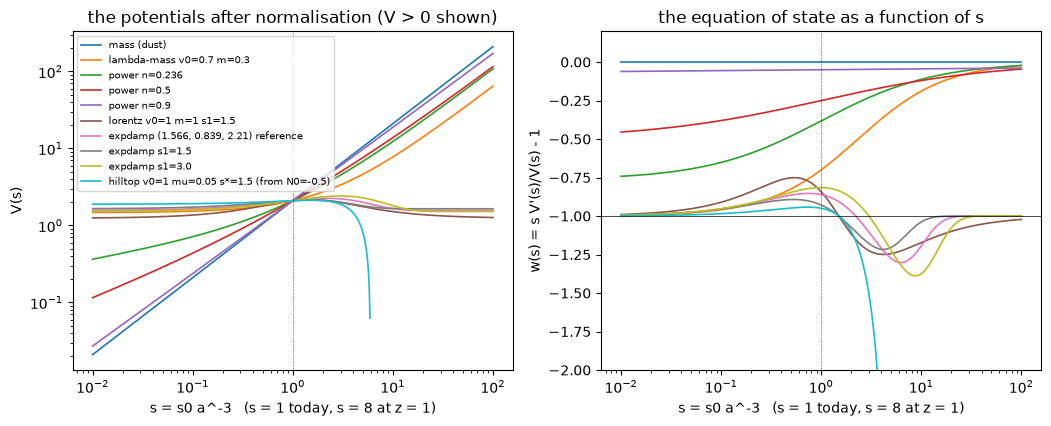

In [6]:
SP_RUNS = ['nb02_mass', 'nb02_lambda-mass', 'nb02_power_n0.236', 'nb02_power_n0.5', 'nb02_power_n0.9', 'nb02_lorentz', 'nb02_expdamp_ref', 'nb02_expdamp_s1.5', 'nb02_expdamp_s3', 'nb02_hilltop']
s_grid = np.geomspace(1e-2, 1e2, 600)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
for n in SP_RUNS:
    V, dV = spinor_potential(RUNS[n]['pot'], RUNS[n]['params'])
    v = V(s_grid); ok = v > 0
    ax1.plot(s_grid[ok], v[ok], lw=1.2, label=RUNS[n]['label'])
    ax2.plot(s_grid[ok], (s_grid * dV(s_grid) / v - 1.0)[ok], lw=1.2, label=RUNS[n]['label'])
for ax in (ax1, ax2):
    ax.set_xscale('log'); ax.axvline(1.0, color='k', lw=0.5, ls=':'); ax.set_xlabel('s = s0 a^-3   (s = 1 today, s = 8 at z = 1)')
ax1.set_yscale('log'); ax1.set_ylabel('V(s)'); ax1.set_title('the potentials after normalisation (V > 0 shown)')
ax2.axhline(-1.0, color='k', lw=0.5); ax2.set_ylim(-2.0, 0.2); ax2.set_ylabel('w(s) = s V\'(s)/V(s) - 1'); ax2.set_title('the equation of state as a function of s')
ax1.legend(fontsize=7); fig.savefig(RESULTS / 'nb02_potentials.png', dpi=130, bbox_inches='tight'); print('figure: results/nb02_potentials.png'); plt.show()

### 5.6 `w(a)` for every run, and the Caldwell–Linder plane

As for the scalar field: the whole run on a logarithmic `a` axis with Unite's CPL line
extrapolated, then the supernova range with each run's own CPL fit dashed, Unite's line
dotted and the constant-w fit dash-dotted.  The dust-like family first, then the family that
crosses the phantom divide.  In the Caldwell–Linder plane the phantom runs sit at `w < −1`
in the past and rise through the divide towards today: their `dw/dN` changes sign over the fit
range, so they are `mixed` by the sign rule.

figure: results/nb02_w_of_a_dust.png


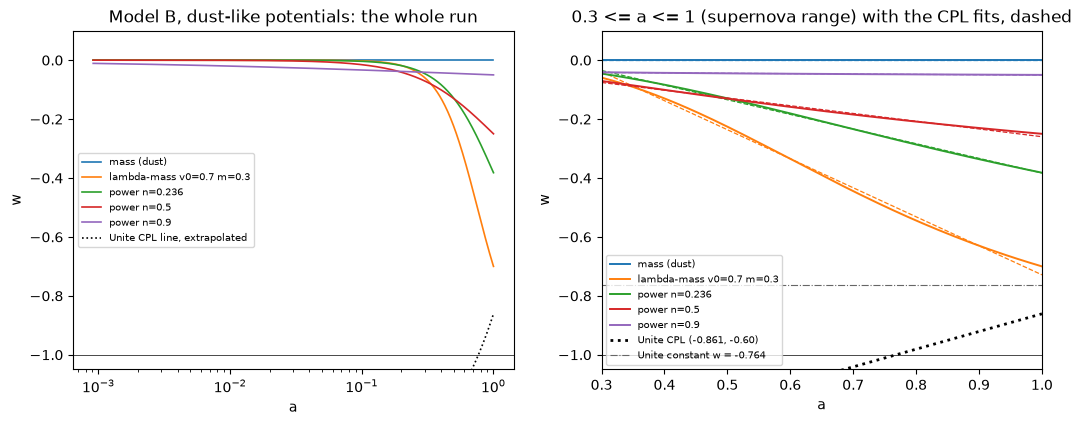

figure: results/nb02_w_of_a_phantom.png


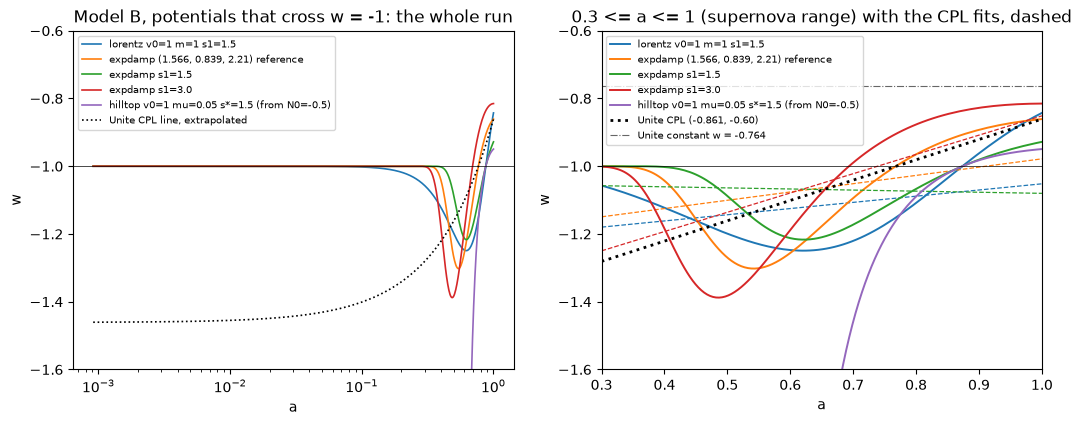

figure: results/nb02_caldwell_linder.png


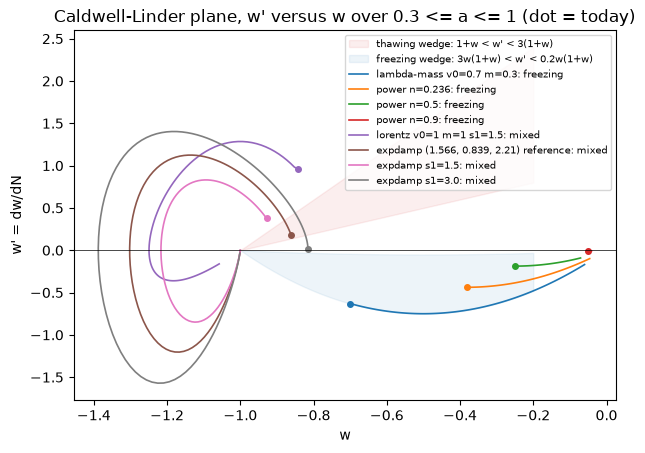

In [7]:
entries = lambda names: [(RUNS[n]['label'], RUNS[n]['table'], 'w_Psi') for n in names]
DUST_RUNS = SP_RUNS[:5]
PHANTOM_RUNS = SP_RUNS[5:]
plot_w_of_a(entries(DUST_RUNS), 'nb02_w_of_a_dust.png', 'Model B, dust-like potentials', ylim=(-1.05, 0.1))
plot_w_of_a(entries(PHANTOM_RUNS), 'nb02_w_of_a_phantom.png', 'Model B, potentials that cross w = -1', ylim=(-1.6, -0.6))
plot_caldwell_linder(entries(SP_RUNS[1:9]), 'nb02_caldwell_linder.png', "Caldwell-Linder plane, w' versus w over 0.3 <= a <= 1")

### 5.7 The crossing of `w = −1`, numerical versus analytic

`crossings` finds every sign change of `w + 1` on the 701-point grid and locates the root with
a local degree-6 polynomial through the eight surrounding points; the analytic value is
`a_c = (s1/s_today)^{−1/3}` (`(s*/s_today)^{−1/3}` for the hilltop).  The difference must be
below `1e−6` for `lorentz` and `expdamp` — asserted; it is in fact about `1e−8`, the size of
CVODE's error on `s` at `rtol = 1e−10`.  `V > 0` on the whole run is checked at the same time.
The table is written to `results/nb02_crossings.csv`.

In [8]:
cross_rows = []
for n in SP_RUNS:
    d = RUNS[n]['table']; p = RUNS[n]['params']
    s_c = p.get('s1', p.get('sstar'))
    a_num = crossings(d['N'], d['w_Psi'])
    a_ana = float(s_c ** (-1.0 / 3.0)) if s_c is not None else float('nan')
    err = abs(a_num[0] - a_ana) if a_num and s_c is not None else float('nan')
    cross_rows.append({'run': RUNS[n]['label'], 'a_cross_numeric': a_num[0] if a_num else float('nan'), 'a_cross_analytic': a_ana, 'abs_error': err,
                       'n_crossings': len(a_num), 'min_V': float(d['U_Psi'].min())})
    print(f"{RUNS[n]['label']:44s} crossings: {len(a_num):d}  a_c numeric = {cross_rows[-1]['a_cross_numeric']:.9f}  analytic = {a_ana:.9f}  |diff| = {err:.2e}   min V = {d['U_Psi'].min():.4f}")
    assert d['U_Psi'].min() > 0.0
    if RUNS[n]['pot'] in ('lorentz', 'expdamp'):
        assert len(a_num) == 1 and err < 1e-6, f'{n}: the crossing must agree with (s1/s0)^(-1/3) to 1e-6'
with open(RESULTS / 'nb02_crossings.csv', 'w', newline='') as f:
    wr = csv.DictWriter(f, fieldnames=list(cross_rows[0].keys())); wr.writeheader(); wr.writerows(cross_rows)
print('written: results/nb02_crossings.csv')

mass (dust)                                  crossings: 0  a_c numeric = nan  analytic = nan  |diff| = nan   min V = 2.0997
lambda-mass v0=0.7 m=0.3                     crossings: 0  a_c numeric = nan  analytic = nan  |diff| = nan   min V = 2.0997
power n=0.236                                crossings: 0  a_c numeric = nan  analytic = nan  |diff| = nan   min V = 2.0997
power n=0.5                                  crossings: 0  a_c numeric = nan  analytic = nan  |diff| = nan   min V = 2.0997
power n=0.9                                  crossings: 0  a_c numeric = nan  analytic = nan  |diff| = nan   min V = 2.0997
lorentz v0=1 m=1 s1=1.5                      crossings: 1  a_c numeric = 0.873580480  analytic = 0.873580465  |diff| = 1.50e-08   min V = 1.2408
expdamp (1.566, 0.839, 2.21) reference       crossings: 1  a_c numeric = 0.767719519  analytic = 0.767719506  |diff| = 1.29e-08   min V = 1.5660
expdamp s1=1.5                               crossings: 1  a_c numeric = 0.873580480  anal

### 5.8 The CPL fit table

For every run: the unweighted least-squares fit of `w(a)` to `w0 + wa (1 − a)` over
`0.3 ≤ a ≤ 1`, the extrapolation `w0 + wa`, the true `w(a = 0.3)`, `w(1)` and `min w`, the
class, `Ω_Ψ` today and the distance from Unite's point, next to Unite's `(−0.861, −0.60,
−1.461)` and the constant-w fit `−0.764`, written to `results/nb02_cpl_fits.csv`.  The
hilltop run starts at `a = 0.61`, so its fit covers `0.61 ≤ a ≤ 1` only and its `w(0.3)` is
undefined (NaN).  A straight line is a poor description of a `w(a)` that dips to −1.3 and
comes back, which is why the phantom runs' `w0 + wa` differ so much from their `min w`.

In [9]:
fits02 = [fit_row(n, 'w_Psi') for n in SP_RUNS]
fit_table(fits02, RESULTS / 'nb02_cpl_fits.csv')

run                                            w0_fit   wa_fit    w0+wa   w(0.3)     w(1)    min w  class     Omega(1)   dist
-----------------------------------------------------------------------------------------------------------------------------
mass (dust)                                    0.0000   0.0000   0.0000   0.0000   0.0000   0.0000  constant    0.6999  1.049
lambda-mass v0=0.7 m=0.3                      -0.7286   0.9850   0.2564  -0.0593  -0.7000  -0.7000  freezing    0.6999  1.591
power n=0.236                                 -0.3830   0.4971   0.1141  -0.0455  -0.3820  -0.3820  freezing    0.6999  1.197
power n=0.5                                   -0.2598   0.2630   0.0032  -0.0706  -0.2500  -0.2500  freezing    0.6999  1.052
power n=0.9                                   -0.0508   0.0128  -0.0381  -0.0411  -0.0500  -0.0500  freezing    0.6999  1.016
lorentz v0=1 m=1 s1=1.5                       -1.0519  -0.1826  -1.2346  -1.0570  -0.8427  -1.2492  mixed       0.6999

### 5.9 Cross-check: every run re-integrated with scipy (DOP853, rtol = 1e−11)

For Model B the scipy system is `ds/dN = −3 s`, `dt/dN = 1/H(N, s)` with the potential as
normalised by the solver; `w` is then the algebraic `s V′(s)/V(s) − 1` of scipy's `s`.  The
cell prints `max |w_rust − w_scipy|` and `max |t_rust − t_scipy|` for every run and fails if a
difference in `w` exceeds `1e−6`.  The differences of a few parts in 10⁸ are CVODE's error on
`s` at `rtol = 1e−10` amplified by the slope `dw/ds` near the phantom dip.

In [10]:
xcheck02 = {}
for n in SP_RUNS + ['nb02_power_n0.236_future']:
    dw, dt, _ = scipy_spinor(n)
    xcheck02[n] = dw
    print(f'{RUNS[n]["label"]:44s} max|w_rust - w_scipy| = {dw:.3e}   max|t_rust - t_scipy| = {dt:.3e}')
    assert dw < 1e-6, f'{n}: the scipy cross-check differs by {dw}'
print(f'\nlargest difference in w over all {len(xcheck02)} runs: {max(xcheck02.values()):.3e}')

mass (dust)                                  max|w_rust - w_scipy| = 0.000e+00   max|t_rust - t_scipy| = 1.090e-08
lambda-mass v0=0.7 m=0.3                     max|w_rust - w_scipy| = 1.257e-08   max|t_rust - t_scipy| = 6.231e-09
power n=0.236                                max|w_rust - w_scipy| = 7.633e-09   max|t_rust - t_scipy| = 8.642e-09
power n=0.5                                  max|w_rust - w_scipy| = 3.269e-09   max|t_rust - t_scipy| = 9.137e-09
power n=0.9                                  max|w_rust - w_scipy| = 1.308e-10   max|t_rust - t_scipy| = 1.043e-08
lorentz v0=1 m=1 s1=1.5                      max|w_rust - w_scipy| = 2.201e-08   max|t_rust - t_scipy| = 1.006e-09
expdamp (1.566, 0.839, 2.21) reference       max|w_rust - w_scipy| = 1.861e-08   max|t_rust - t_scipy| = 4.875e-10
expdamp s1=1.5                               max|w_rust - w_scipy| = 1.398e-08   max|t_rust - t_scipy| = 5.294e-10
expdamp s1=3.0                               max|w_rust - w_scipy| = 2.387e-08  

### 5.10 Three integrators on the reference case: CVODE (Rust), DOP853 (scipy), NDSolve (Mathematica)

`reference/mathematica_spinor_expdamp.csv` was written by Part VI of the Mathematica notebook
(`reference/make_reference.wls`) for `expdamp (1.566, 0.839, 2.21)` without normalisation:
`s = e^{−3N}` in closed form, `t` by `NDSolve` at 24-digit working precision, on the same 701
values of `N`.  The cell compares the three on `w`, and Rust against Mathematica on `s`, `H`,
`ρ_Ψ` and `t`.

In [11]:
ref = np.genfromtxt(REFERENCE / 'mathematica_spinor_expdamp.csv', delimiter=',', names=True)
d = RUNS['nb02_expdamp_ref']['table']
assert ref.shape == d.shape and np.abs(ref['N'] - d['N']).max() < 1e-12, 'the reference grid must be the solver grid'
_, _, w_scipy = scipy_spinor('nb02_expdamp_ref')
threeway02 = {'rust-mathematica': float(np.abs(ref['w_Psi'] - d['w_Psi']).max()),
              'scipy-mathematica': float(np.abs(ref['w_Psi'] - w_scipy).max()),
              'rust-scipy': float(np.abs(d['w_Psi'] - w_scipy).max())}
for k, v in threeway02.items():
    print(f'max |w difference| {k:18s} = {v:.3e}')
for c in ['s', 'H', 'rho_Psi', 't']:
    print(f'max relative |{c} rust - mathematica| = {(np.abs(ref[c] - d[c]) / np.abs(ref[c])).max():.3e}')
print(f'w(a=1): rust {d["w_Psi"][-1]:.12f}  scipy {w_scipy[-1]:.12f}  mathematica {ref["w_Psi"][-1]:.12f}')
assert threeway02['rust-mathematica'] < 1e-6 and threeway02['rust-scipy'] < 1e-6

max |w difference| rust-mathematica   = 1.861e-08
max |w difference| scipy-mathematica  = 1.008e-11
max |w difference| rust-scipy         = 1.861e-08
max relative |s rust - mathematica| = 5.235e-08
max relative |H rust - mathematica| = 2.549e-09
max relative |rho_Psi rust - mathematica| = 1.441e-08
max relative |t rust - mathematica| = 6.124e-07
w(a=1): rust -0.860845643423  scipy -0.860845640379  mathematica -0.860845640378


## 6. This notebook's results

Everything this notebook writes lives under `results/`:

- `results/nb02_mass.csv`, `results/nb02_lambda-mass.csv`, `results/nb02_power_n0.236.csv`,
  `results/nb02_power_n0.5.csv`, `results/nb02_power_n0.9.csv`, `results/nb02_power_n0.236_future.csv`;
- `results/nb02_lorentz.csv`, `results/nb02_expdamp_ref.csv`, `results/nb02_expdamp_s1.5.csv`,
  `results/nb02_expdamp_s3.csv`, `results/nb02_hilltop.csv` (the refused default-start hilltop writes nothing);
- `results/nb02_crossings.csv` — the crossing table of 5.7; `results/nb02_cpl_fits.csv` — the CPL table of 5.8;
- `results/nb02_potentials.png`, `results/nb02_w_of_a_dust.png`, `results/nb02_w_of_a_phantom.png`,
  `results/nb02_caldwell_linder.png` — the figures.

The cell below reads the crossing table back with Python's `csv` module alone (no numpy, no
solver) and prints it.

In [12]:
import csv
with open(RESULTS / 'nb02_crossings.csv', newline='') as f:
    rows = list(csv.DictReader(f))
print(f'{len(rows)} rows, columns: {", ".join(rows[0].keys())}')
for r in rows:
    print(f"{r['run']:44s} crossings = {r['n_crossings']}  a_c numeric = {float(r['a_cross_numeric']):.6f}  analytic = {float(r['a_cross_analytic']):.6f}  min V = {float(r['min_V']):.4f}")

10 rows, columns: run, a_cross_numeric, a_cross_analytic, abs_error, n_crossings, min_V
mass (dust)                                  crossings = 0  a_c numeric = nan  analytic = nan  min V = 2.0997
lambda-mass v0=0.7 m=0.3                     crossings = 0  a_c numeric = nan  analytic = nan  min V = 2.0997
power n=0.236                                crossings = 0  a_c numeric = nan  analytic = nan  min V = 2.0997
power n=0.5                                  crossings = 0  a_c numeric = nan  analytic = nan  min V = 2.0997
power n=0.9                                  crossings = 0  a_c numeric = nan  analytic = nan  min V = 2.0997
lorentz v0=1 m=1 s1=1.5                      crossings = 1  a_c numeric = 0.873580  analytic = 0.873580  min V = 1.2408
expdamp (1.566, 0.839, 2.21) reference       crossings = 1  a_c numeric = 0.767720  analytic = 0.767720  min V = 1.5660
expdamp s1=1.5                               crossings = 1  a_c numeric = 0.873580  analytic = 0.873580  min V = 1.6468
ex

## 7. The questions, answered from the numbers

**Which potential gives a genuine phantom phase in the past with `w(1) ≈ −0.86`, and what are
its fitted `(w0, wa)`?**  The reference `expdamp` potential, `V = V0 + m s e^{−s/s1}` with
`(V0, m, s1) = (1.566, 0.839, 2.21)`: `w(1) = −0.861`, `w` crosses −1 at `a_c = 0.7677`
(`z = 0.30`, the analytic `2.21^{−1/3}`), reaches its minimum `w = −1.302` at `a = 0.543`
(`z = 0.84`) and tends to −1 from below as `a → 0` — a *genuine* `w < −1` with `ρ_Ψ = V > 0`
everywhere (`min V = 1.566`), produced by the sign change of `V′` at `s = s1` and no wrong-sign
kinetic term.  Its unweighted CPL fit over `0.3 ≤ a ≤ 1` is `(w0, wa) = (−0.978, −0.245)`,
`w0 + wa = −1.22`; the straight line misses both the dip and today's value because `w(a)` is
strongly curved there.  The `lorentz` potential does the same with `w(1) = −0.843`, minimum
`−1.249`, crossing at `a_c = 0.8736 = 1.5^{−1/3}`, fit `(−1.052, −0.183)`.  Of every run in
this notebook the one closest to Unite's *fitted* numbers is `expdamp` with `s1 = 3.0`:
`(w0, wa) = (−0.851, −0.569)`, `w0 + wa = −1.42` (Unite: `−0.861, −0.60, −1.46`), with
`w(1) = −0.815`, a crossing at `a_c = 0.693` (`z = 0.44`) and a minimum of `−1.388` — a spinor
with a phantom past, not a straight line, reproduces the Unite CPL numbers to a few hundredths.

**Dust and Λ.**  The mass term is `w = 0` to machine precision at all 701 points (the author's
spinor is cold dark matter, exactly).  `lambda-mass` is ΛCDM in disguise: `Ω_Λ = V(0)/3 = 0.490`
is a bare constant in the action and the spinor supplies dust with `Ω = 0.210`; `w(1) = −0.700`.
The power law `n = 0.236` is dust early (`w(a = 0.1) = −0.004`), has `w(1) = −0.382` with
`m = λ`, and reaches Unite's constant-w value `−0.764` only asymptotically (`w(a = e⁶) + 0.764
= 8e−7`): field-driven dark energy, in the sense that no constant is added to the action, but
with the wrong timing unless `m ≪ λ`.  The hilltop crosses at `a_c = 0.8736` too but is valid
only for `a > 0.55`; the solver refuses it from the default start, as it must.

The cell below re-derives every number quoted in this section from the tables and fails if the
text has gone stale.

In [13]:
F = {r['run']: r for r in fits02}
C = {r['run']: r for r in cross_rows}
E = F['expdamp (1.566, 0.839, 2.21) reference']
d = RUNS['nb02_expdamp_ref']['table']
assert abs(E['w_a1'] + 0.861) < 1e-3 and abs(E['w_min'] + 1.302) < 1e-3 and abs(d['a'][d['w_Psi'].argmin()] - 0.543) < 2e-3
assert abs(C[E['run']]['a_cross_numeric'] - 0.7677) < 1e-4 and abs(E['w0_fit'] + 0.978) < 1e-3 and abs(E['wa_fit'] + 0.245) < 1e-3 and abs(E['w0_plus_wa'] + 1.22) < 5e-3
L = F['lorentz v0=1 m=1 s1=1.5']
assert abs(L['w_a1'] + 0.843) < 1e-3 and abs(L['w_min'] + 1.249) < 1e-3 and abs(C[L['run']]['a_cross_numeric'] - 0.8736) < 1e-4 and abs(L['w0_fit'] + 1.052) < 1e-3 and abs(L['wa_fit'] + 0.183) < 1e-3
S3 = F['expdamp s1=3.0']
closest = min(fits02, key=lambda r: r['dist_to_unite'])
assert closest['run'] == S3['run'] and abs(S3['w0_fit'] + 0.851) < 1e-3 and abs(S3['wa_fit'] + 0.569) < 1e-3 and abs(S3['w0_plus_wa'] + 1.42) < 5e-3
assert abs(S3['w_a1'] + 0.815) < 1e-3 and abs(C[S3['run']]['a_cross_numeric'] - 0.693) < 1e-3 and abs(S3['w_min'] + 1.388) < 1e-3
assert abs(omega_lambda - 0.490) < 1e-3 and abs(omega_dust - 0.210) < 1e-3 and abs(F['lambda-mass v0=0.7 m=0.3']['w_a1'] + 0.700) < 1e-3
P = RUNS['nb02_power_n0.236']['table']
assert abs(P['w_Psi'][-1] + 0.382) < 1e-3 and abs(w_at(P['a'], P['w_Psi'], 0.1) + 0.004) < 1e-3
assert abs(RUNS['nb02_power_n0.236_future']['table']['w_Psi'][-1] + 0.764) < 2e-6
assert abs(C['hilltop v0=1 mu=0.05 s*=1.5 (from N0=-0.5)']['a_cross_numeric'] - 0.8736) < 1e-4
print('closest run to Unite in the (w0, wa) plane:', closest['run'], f"({closest['w0_fit']:+.4f}, {closest['wa_fit']:+.4f}), distance {closest['dist_to_unite']:.4f}")
print('every number quoted in section 7 agrees with the tables')

closest run to Unite in the (w0, wa) plane: expdamp s1=3.0 (-0.8513, -0.5692), distance 0.0323
every number quoted in section 7 agrees with the tables


## 8. Name this notebook and save it

The last two cells are the interactive ones.  The first asks you for a name for this notebook
(press Enter to keep the current one); the second opens the usual graphical *Save as* dialog so
you can put a copy of the notebook -- with all the outputs you have just produced -- wherever you
like.  When the notebook is executed headlessly (by `run_all.sh`, `run_all.ps1` or `nbconvert`)
there is nobody to answer, so both cells detect that and print a one-line notice instead.

In [14]:
import os, sys

def headless_now():
    """True when nobody can answer a prompt: nbconvert / nbclient execution (the kernel's stdin is
    disabled), a FABLE_HEADLESS environment variable, or a plain Python run without a terminal."""
    if os.environ.get('FABLE_HEADLESS'):
        return True
    try:
        return not get_ipython().kernel._allow_stdin
    except Exception:
        return not sys.stdin.isatty()

HEADLESS = headless_now()
if HEADLESS:
    NOTEBOOK_NAME = '02_fable_spinor'
    print('Headless execution: no prompt; the notebook keeps its name', NOTEBOOK_NAME)
else:
    NOTEBOOK_NAME = input('Name for this notebook: ').strip() or '02_fable_spinor'
    print('This notebook is called', NOTEBOOK_NAME)

Headless execution: no prompt; the notebook keeps its name 02_fable_spinor


If the graphical dialog cannot be opened (no display, or Tk missing from your Python), the cell
falls back to asking for a folder path in plain text and copies the notebook there.

In [15]:
import shutil
from pathlib import Path

if globals().get('HEADLESS', True):
    print('Headless execution: the save dialog is skipped; the notebook stays where it is.')
else:
    target = ''
    try:
        import tkinter
        from tkinter import filedialog
        root = tkinter.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        target = filedialog.asksaveasfilename(title='Save a copy of this notebook as',
                                              initialfile=NOTEBOOK_NAME + '.ipynb', defaultextension='.ipynb',
                                              filetypes=[('Jupyter notebook', '*.ipynb'), ('All files', '*.*')])
        root.destroy()
    except Exception as exc:
        print(f'No graphical dialog is available ({exc}). Falling back to a typed folder path.')
        folder = input('Folder to save a copy of this notebook into (empty = do not save): ').strip()
        if folder:
            target = str(Path(folder) / (NOTEBOOK_NAME + '.ipynb'))
    if target:
        shutil.copyfile(Path.cwd() / '02_fable_spinor.ipynb', target)
        print('A copy of this notebook was saved as', target)
    else:
        print('Nothing saved.')

Headless execution: the save dialog is skipped; the notebook stays where it is.
